# 🚦 Traffic Signal & Violation Analytics — Machine Learning Project

**End-to-end ML pipeline** (classical ML only, no deep learning) built on the *Smart Traffic Signal & Violation Analytics* dataset — 15 junctions, 6 months, 26,000 vehicle observations.

**Pipeline:** Data Cleaning → EDA → Feature Engineering → Supervised Classification (binary + multiclass) → Regression → Unsupervised Clustering → Model Evaluation → Model Persistence

**Tasks solved:**
1. Predict whether a vehicle will commit a rule violation (binary classification)
2. Predict *which* violation type it is, given a violation occurred (multiclass classification)
3. Predict signal waiting time (regression)
4. Segment junctions into risk clusters (unsupervised — K-Means)

---


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                              confusion_matrix, RocCurveDisplay, classification_report,
                              mean_absolute_error, mean_squared_error, r2_score, silhouette_score)

sns.set_theme(style="darkgrid")
pd.set_option("display.max_columns", 50)

RAW_PATH = "data/Traffic_Facts.csv"


## 2. Data Cleaning

The raw `Traffic_Facts.csv` is **intentionally messy** (this mirrors a real-world extract):
- Inconsistent `Vehicle_Type` casing/naming (`bike`, `BIKE`, `Two Wheeler`)
- Mixed date formats (`YYYY-MM-DD`, `DD-MM-YYYY`, `MM/DD/YYYY`, `DD Mon YYYY`)
- Mixed 12h/24h time text
- Duplicate rows, nulls in a few columns

We clean it here, then merge in the dimension tables (`Junction_Master.csv`, `Signal_Master.csv`) to build a single feature-rich table.


In [2]:
def clean_vehicle_type(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    mapping = {
        "bike": "Bike", "two wheeler": "Bike", "two-wheeler": "Bike",
        "car": "Car", "truck": "Truck", "auto": "Auto", "auto rickshaw": "Auto",
        "bus": "Bus", "taxi": "Taxi", "cab": "Taxi",
    }
    return mapping.get(x, x.title())

def parse_mixed_date(x):
    if pd.isna(x):
        return pd.NaT
    x = str(x).strip()
    for fmt in ("%Y-%m-%d", "%d-%m-%Y", "%m/%d/%Y", "%d %b %Y"):
        try:
            return pd.to_datetime(x, format=fmt)
        except ValueError:
            continue
    return pd.to_datetime(x, errors="coerce")

def parse_mixed_time(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    ampm = bool(re.search(r"[APap][Mm]", x))
    fmt = "%I:%M:%S %p" if ampm else "%H:%M:%S"
    try:
        t = pd.to_datetime(x, format=fmt).time()
        return t.hour * 3600 + t.minute * 60 + t.second
    except ValueError:
        return np.nan


In [3]:
facts = pd.read_csv("data/Traffic_Facts.csv")
junction = pd.read_csv("data/Junction_Master.csv")
vehicle = pd.read_csv("data/Vehicle_Master.csv")
signal = pd.read_csv("data/Signal_Master.csv")
violation = pd.read_csv("data/Violation_Master.csv")
print("Raw Traffic_Facts:", facts.shape)
facts.head()


Raw Traffic_Facts: (26104, 28)


,Record_ID,Date,Time,Junction_ID,Vehicle_ID,Vehicle_Type,Direction,Lane,Signal_State,Signal_Duration,Waiting_Time,Vehicle_Speed,Speed_Limit,Helmet,Seat_Belt,Stop_Line_Crossed,Lane_Compliance,Phone_Usage,U_Turn,U_Turn_Allowed,Overloading,Violation,Violation_Type,Fine_Amount,Accident,Weather,Road_Condition,Traffic_Density
0,R006382,2026-05-31,10:25:58,J002,TN09-9690-P01149,Car,East,4.0,Green,166,17.0,41.1,60,NaN,Yes,No,Yes,No,No,No,No,No,NaN,0,No,Clear,Good,79.2
1,R019075,2026-03-08,17:31:16,J015,MH14-3442-B00034,car,East,2.0,Red,172,69.2,29.7,40,NaN,No,No,Yes,No,No,Yes,No,Yes,No Seat Belt,1000,No,Rain,Good,70.7
2,R025818,2026-05-24,15:49:42,J002,MH14-7366-E04864,Truck,North,2.0,Green,166,1.6,34.1,60,NaN,Yes,No,Yes,No,No,No,Yes,Yes,Overloading,2000,No,Clear,Good,36.6
3,R016970,2026-03-08,23:33:41,J002,TN09-1272-M01416,Bike,West,1.0,Green,166,0.0,38.9,60,Yes,NaN,No,Yes,No,No,Yes,No,No,NaN,0,No,Clear,Good,24.7
4,R014166,2026-04-09,06:35:28,J002,TN09-8859-R00492,Auto,West,1.0,Green,166,1.4,33.4,60,NaN,NaN,No,Yes,No,No,Yes,No,No,NaN,0,No,Clear,Good,14.5


In [4]:
# text cleanup (preserve real nulls, don't touch the literal "None" category)
text_cols = facts.select_dtypes(include="object").columns
for c in text_cols:
    was_null = facts[c].isna()
    facts[c] = facts[c].astype(str).str.strip()
    facts.loc[was_null, c] = np.nan
    facts[c] = facts[c].replace({"nan": np.nan})

facts["Junction_ID"] = facts["Junction_ID"].str.upper()
facts["Vehicle_Type"] = facts["Vehicle_Type"].apply(clean_vehicle_type)

facts["Date"] = facts["Date"].apply(parse_mixed_date)
facts["Time_Seconds"] = facts["Time"].apply(parse_mixed_time)
facts["Hour"] = (facts["Time_Seconds"] // 3600).astype("Int64")

before = len(facts)
facts = facts.drop_duplicates(subset="Record_ID", keep="first")
print(f"Removed {before - len(facts)} duplicate rows")

for c in ["Helmet", "Seat_Belt", "Weather", "Road_Condition"]:
    facts[c] = facts[c].fillna("Unknown")
facts["Lane"] = facts["Lane"].fillna(facts["Lane"].median())
facts["Violation_Type"] = facts["Violation_Type"].fillna("None")  # blank = no violation occurred


Removed 104 duplicate rows


In [5]:
facts = facts.merge(
    junction[["Junction_ID", "Junction_Name", "Road_Type", "Number_of_Lanes",
              "Signal_Type", "Speed_Limit", "Road_Condition"]]
    .rename(columns={"Speed_Limit": "Junction_Speed_Limit", "Road_Condition": "Junction_Road_Condition"}),
    on="Junction_ID", how="left"
)
facts = facts.merge(
    signal[["Junction_ID", "Red_Duration", "Yellow_Duration", "Green_Duration", "Cycle_Time"]],
    on="Junction_ID", how="left"
)

facts["Is_Peak_Hour"] = facts["Hour"].apply(lambda h: 1 if (8 <= h <= 10 or 17 <= h <= 20) else 0)
facts["Day_Of_Week"] = facts["Date"].dt.day_name()
facts["Is_Weekend"] = facts["Date"].dt.dayofweek.isin([5, 6]).astype(int)
facts["Speed_Over_Limit"] = facts["Vehicle_Speed"] - facts["Speed_Limit"]
facts["Signal_Efficiency"] = facts["Green_Duration"] / facts["Cycle_Time"]

df = facts.copy()
print("Cleaned dataset:", df.shape)
print("Remaining nulls:\n", df.isna().sum()[df.isna().sum() > 0])
df.head()


Cleaned dataset: (26000, 45)
Remaining nulls:
 Series([], dtype: int64)


,Record_ID,Date,Time,Junction_ID,Vehicle_ID,Vehicle_Type,Direction,Lane,Signal_State,Signal_Duration,Waiting_Time,Vehicle_Speed,Speed_Limit,Helmet,Seat_Belt,Stop_Line_Crossed,Lane_Compliance,Phone_Usage,U_Turn,U_Turn_Allowed,Overloading,Violation,Violation_Type,Fine_Amount,Accident,Weather,Road_Condition,Traffic_Density,Time_Seconds,Hour,Junction_Name,Road_Type,Number_of_Lanes,Signal_Type,Junction_Speed_Limit,Junction_Road_Condition,Red_Duration,Yellow_Duration,Green_Duration,Cycle_Time,Is_Peak_Hour,Day_Of_Week,Is_Weekend,Speed_Over_Limit,Signal_Efficiency
0,R006382,2026-05-31,10:25:58,J002,TN09-9690-P01149,Car,East,4.0,Green,166,17.0,41.1,60,Unknown,Yes,No,Yes,No,No,No,No,No,None,0,No,Clear,Good,79.2,37558,10,College Road Junction,Main Road,4,Automatic,60,Good,90,3,73,166,1,Sunday,1,-18.9,0.439759
1,R019075,2026-03-08,17:31:16,J015,MH14-3442-B00034,Car,East,2.0,Red,172,69.2,29.7,40,Unknown,No,No,Yes,No,No,Yes,No,Yes,No Seat Belt,1000,No,Rain,Good,70.7,63076,17,Civil Lines Junction,Residential,3,Manual,40,Good,79,5,88,172,1,Sunday,1,-10.3,0.511628
2,R025818,2026-05-24,15:49:42,J002,MH14-7366-E04864,Truck,North,2.0,Green,166,1.6,34.1,60,Unknown,Yes,No,Yes,No,No,No,Yes,Yes,Overloading,2000,No,Clear,Good,36.6,56982,15,College Road Junction,Main Road,4,Automatic,60,Good,90,3,73,166,0,Sunday,1,-25.9,0.439759
3,R016970,2026-03-08,23:33:41,J002,TN09-1272-M01416,Bike,West,1.0,Green,166,0.0,38.9,60,Yes,Unknown,No,Yes,No,No,Yes,No,No,None,0,No,Clear,Good,24.7,84821,23,College Road Junction,Main Road,4,Automatic,60,Good,90,3,73,166,0,Sunday,1,-21.1,0.439759
4,R014166,2026-04-09,06:35:28,J002,TN09-8859-R00492,Auto,West,1.0,Green,166,1.4,33.4,60,Unknown,Unknown,No,Yes,No,No,Yes,No,No,None,0,No,Clear,Good,14.5,23728,6,College Road Junction,Main Road,4,Automatic,60,Good,90,3,73,166,0,Thursday,0,-26.6,0.439759


## 3. Exploratory Data Analysis

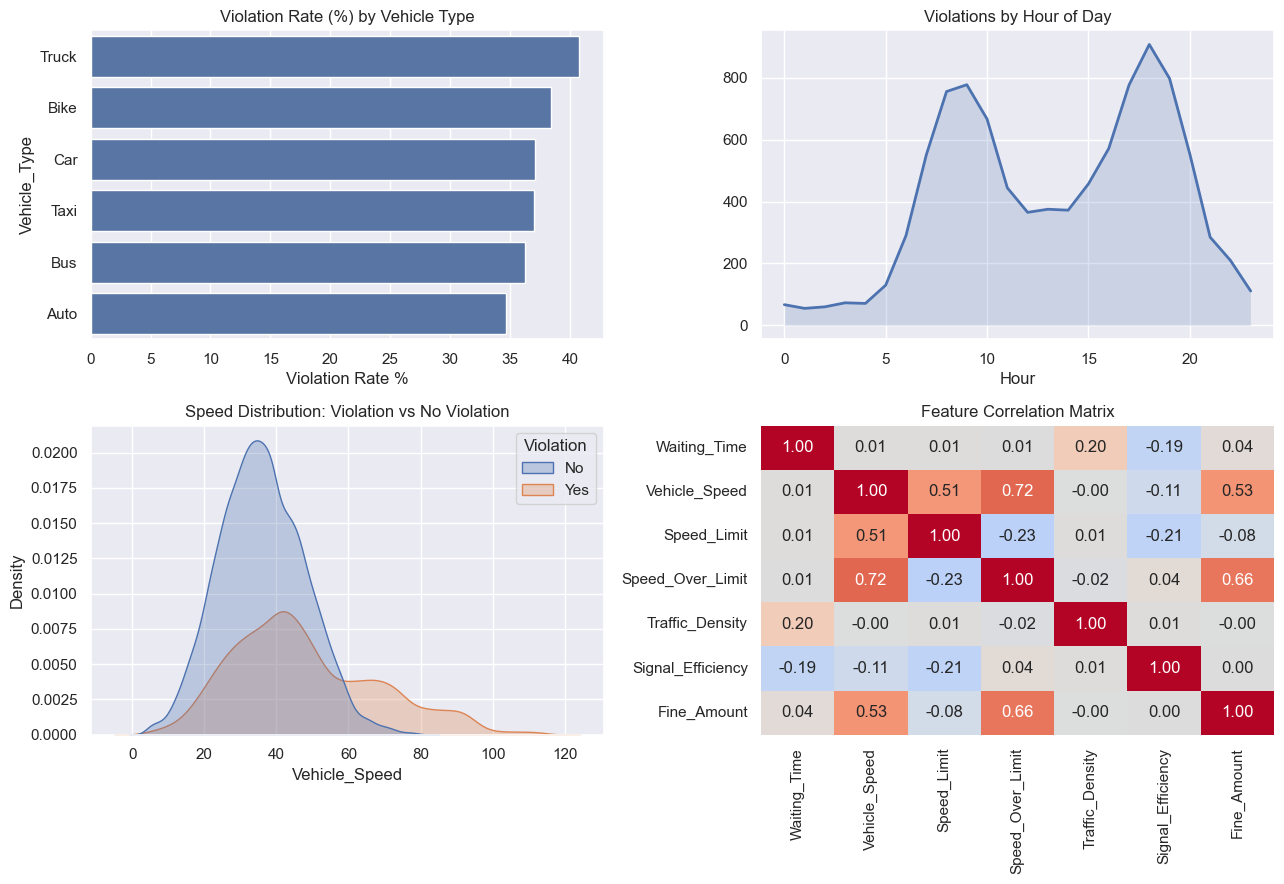

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

vt = df.groupby("Vehicle_Type")["Violation"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
sns.barplot(x=vt.values, y=vt.index, ax=axes[0, 0])
axes[0, 0].set_title("Violation Rate (%) by Vehicle Type")
axes[0, 0].set_xlabel("Violation Rate %")

hr = df[df.Violation == "Yes"].groupby("Hour").size()
axes[0, 1].plot(hr.index, hr.values, linewidth=2)
axes[0, 1].fill_between(hr.index, hr.values, alpha=0.2)
axes[0, 1].set_title("Violations by Hour of Day")
axes[0, 1].set_xlabel("Hour")

sns.kdeplot(data=df, x="Vehicle_Speed", hue="Violation", ax=axes[1, 0], fill=True, alpha=0.3)
axes[1, 0].set_title("Speed Distribution: Violation vs No Violation")

num_cols = ["Waiting_Time", "Vehicle_Speed", "Speed_Limit", "Speed_Over_Limit",
            "Traffic_Density", "Signal_Efficiency", "Fine_Amount"]
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1], cbar=False, center=0)
axes[1, 1].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()


In [7]:
print("Overall violation rate: {:.1f}%".format((df.Violation == "Yes").mean() * 100))
print("Total fine collected: ₹{:,}".format(df["Fine_Amount"].sum()))
print("Total accidents:", (df.Accident == "Yes").sum())
df.groupby("Junction_Name")["Violation"].apply(lambda s: (s == "Yes").sum()).sort_values(ascending=False).head(5)


Overall violation rate: 37.4%
Total fine collected: ₹13,228,000
Total accidents: 307


Junction_Name
Industrial Area Junction    734
Tech Park Junction          733
Railway Station Junction    725
Highway Entry Junction      695
Civil Lines Junction        689
Name: Violation, dtype: int64

## 4. Model 1 — Violation Classifier (Binary Classification)

**Important design decision:** features like `Helmet`, `Seat_Belt`, `Phone_Usage`, `Lane_Compliance` are **excluded**, even though present in the raw data. These are the direct rule-inputs that *define* the `Violation` label — including them makes the task a trivial lookup (>99% accuracy) instead of genuine prediction. We predict from **contextual** signals only (time, weather, vehicle type, speed vs. limit, traffic density, signal state) — the realistic use case of estimating risk *before* observing driver behavior.


In [8]:
FEATURES_NUM = ["Hour", "Is_Peak_Hour", "Is_Weekend", "Vehicle_Speed", "Speed_Limit",
                 "Speed_Over_Limit", "Traffic_Density", "Waiting_Time", "Signal_Efficiency",
                 "Number_of_Lanes", "Lane"]
FEATURES_CAT = ["Vehicle_Type", "Signal_State", "Weather", "Road_Type", "Junction_Road_Condition",
                 "Direction", "Signal_Type"]
TARGET = "Violation"

X = df[FEATURES_NUM + FEATURES_CAT]
y = (df[TARGET] == "Yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}, Positive rate: {y.mean():.3f}")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
])


Train: (20800, 18), Test: (5200, 18), Positive rate: 0.374


In [9]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5,
                                             class_weight="balanced", random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.08, random_state=42),
}

results = {}
fitted_pipelines = {}
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    results[name] = {
        "accuracy": accuracy_score(y_test, pred), "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred), "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
    }
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).T.round(4)
results_df


,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.6579,0.5388,0.5857,0.5613,0.7016
RandomForest,0.7756,0.9826,0.4066,0.5752,0.7181
GradientBoosting,0.7758,0.9899,0.4040,0.5738,0.7183


Best model by F1: RandomForest


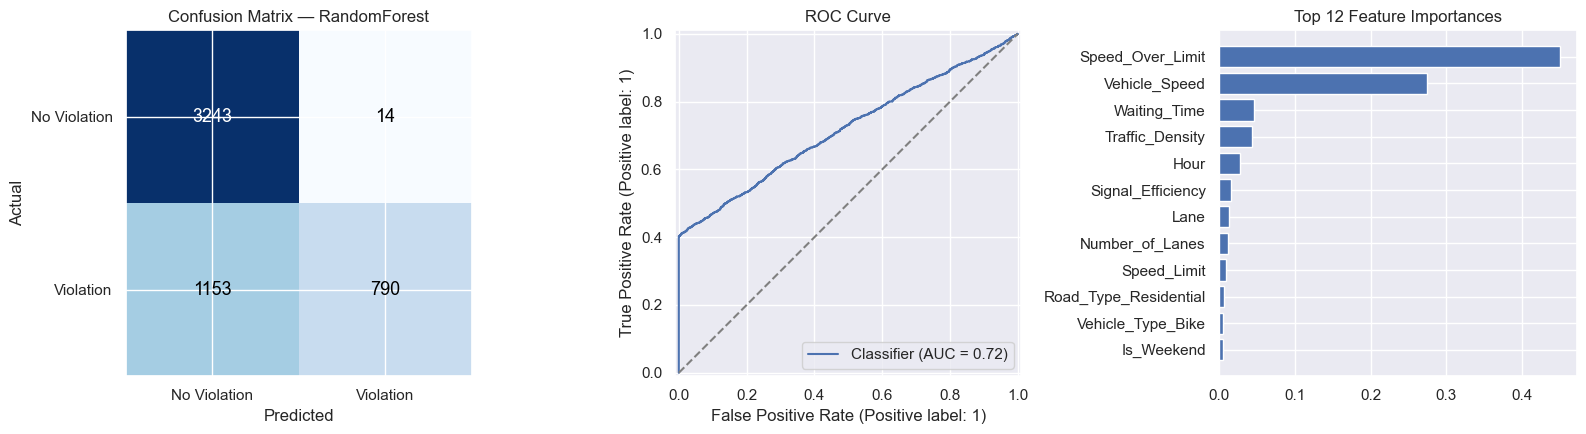

              precision    recall  f1-score   support

No Violation       0.74      1.00      0.85      3257
   Violation       0.98      0.41      0.58      1943

    accuracy                           0.78      5200
   macro avg       0.86      0.70      0.71      5200
weighted avg       0.83      0.78      0.75      5200



In [10]:
best_name = results_df["f1"].idxmax()
best_pipe = fitted_pipelines[best_name]
print("Best model by F1:", best_name)

pred = best_pipe.predict(X_test)
proba = best_pipe.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm = confusion_matrix(y_test, pred)
axes[0].imshow(cm, cmap="Blues")
axes[0].set_title(f"Confusion Matrix — {best_name}")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["No Violation", "Violation"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["No Violation", "Violation"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=13,
                      color="white" if cm[i,j] > cm.max()/2 else "black")

RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve")

ohe = best_pipe.named_steps["prep"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(FEATURES_CAT)
all_names = FEATURES_NUM + list(cat_names)
if hasattr(best_pipe.named_steps["clf"], "feature_importances_"):
    importances = best_pipe.named_steps["clf"].feature_importances_
else:
    importances = np.abs(best_pipe.named_steps["clf"].coef_[0])
top_idx = np.argsort(importances)[-12:]
axes[2].barh([all_names[i] for i in top_idx], importances[top_idx])
axes[2].set_title("Top 12 Feature Importances")

plt.tight_layout()
plt.show()

print(classification_report(y_test, pred, target_names=["No Violation", "Violation"]))


In [11]:
joblib.dump(best_pipe, "models/violation_classifier.pkl")
print("Saved models/violation_classifier.pkl")


Saved models/violation_classifier.pkl


## 5. Model 2 — Violation Type Classifier (Multiclass)

Given a violation occurred, predict *which* of the 8 violation types it is.


In [12]:
vdf = df[df["Violation"] == "Yes"].copy()
print("Violation-only subset:", vdf.shape)

FEATURES_NUM2 = ["Hour", "Is_Peak_Hour", "Is_Weekend", "Vehicle_Speed", "Speed_Limit",
                  "Speed_Over_Limit", "Traffic_Density", "Waiting_Time"]
FEATURES_CAT2 = ["Vehicle_Type", "Signal_State", "Weather", "Road_Type"]

X2 = vdf[FEATURES_NUM2 + FEATURES_CAT2]
le = LabelEncoder()
y2 = le.fit_transform(vdf["Violation_Type"])
print("Classes:", list(le.classes_))

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

preprocessor2 = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM2),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT2),
])

clf2 = RandomForestClassifier(n_estimators=300, max_depth=14, min_samples_leaf=3,
                                class_weight="balanced", random_state=42, n_jobs=-1)
pipe2 = Pipeline([("prep", preprocessor2), ("clf", clf2)])
pipe2.fit(X2_train, y2_train)
pred2 = pipe2.predict(X2_test)

print(f"Accuracy: {accuracy_score(y2_test, pred2):.4f}  Macro-F1: {f1_score(y2_test, pred2, average='macro'):.4f}")
print(classification_report(y2_test, pred2, target_names=le.classes_))


Violation-only subset: (9717, 45)
Classes: ['Illegal U-Turn', 'Mobile Phone Usage', 'No Helmet', 'No Seat Belt', 'Over Speeding', 'Overloading', 'Red Light Jumping', 'Wrong Lane']


Accuracy: 0.6286  Macro-F1: 0.3701
                    precision    recall  f1-score   support

    Illegal U-Turn       0.18      0.04      0.06       107
Mobile Phone Usage       0.14      0.02      0.03       195
         No Helmet       0.47      0.93      0.62       187
      No Seat Belt       0.42      0.61      0.50       221
     Over Speeding       1.00      1.00      1.00       794
       Overloading       0.29      0.80      0.43        64
 Red Light Jumping       0.26      0.37      0.31       163
        Wrong Lane       0.14      0.01      0.02       213

          accuracy                           0.63      1944
         macro avg       0.36      0.47      0.37      1944
      weighted avg       0.57      0.63      0.57      1944



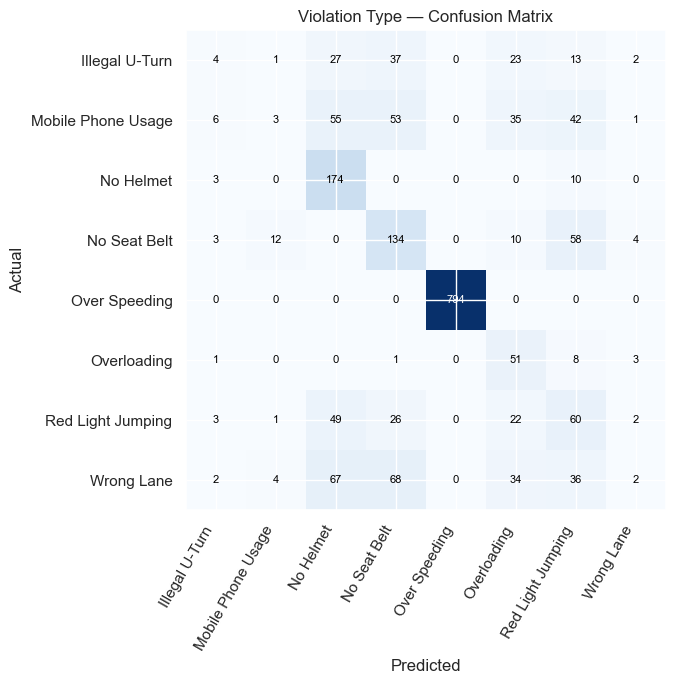

Saved models/violation_type_classifier.pkl


In [13]:
cm2 = confusion_matrix(y2_test, pred2)
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(cm2, cmap="Blues")
ax.set_xticks(range(len(le.classes_))); ax.set_xticklabels(le.classes_, rotation=60, ha="right")
ax.set_yticks(range(len(le.classes_))); ax.set_yticklabels(le.classes_)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Violation Type — Confusion Matrix")
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax.text(j, i, cm2[i, j], ha="center", va="center", fontsize=8,
                 color="white" if cm2[i,j] > cm2.max()/2 else "black")
plt.tight_layout()
plt.show()

joblib.dump({"pipeline": pipe2, "label_encoder": le}, "models/violation_type_classifier.pkl")
print("Saved models/violation_type_classifier.pkl")


## 6. Model 3 — Waiting Time Regressor

Predict signal waiting time (seconds) from junction/signal/traffic context — useful for "what happens if we retime this signal?" simulations.


In [14]:
FEATURES_NUM3 = ["Traffic_Density", "Red_Duration", "Yellow_Duration", "Green_Duration",
                   "Cycle_Time", "Signal_Efficiency", "Hour", "Is_Peak_Hour"]
FEATURES_CAT3 = ["Signal_State", "Road_Type", "Weather"]

X3 = df[FEATURES_NUM3 + FEATURES_CAT3]
y3 = df["Waiting_Time"]
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

preprocessor3 = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM3),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT3),
])

reg_models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=250, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1),
}

best_r2, best_reg_name, best_reg_pipe = -np.inf, None, None
for name, reg in reg_models.items():
    p = Pipeline([("prep", preprocessor3), ("reg", reg)])
    p.fit(X3_train, y3_train)
    pred3 = p.predict(X3_test)
    mae = mean_absolute_error(y3_test, pred3)
    rmse = mean_squared_error(y3_test, pred3) ** 0.5
    r2 = r2_score(y3_test, pred3)
    print(f"{name}: MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.3f}")
    if r2 > best_r2:
        best_r2, best_reg_name, best_reg_pipe = r2, name, p

print("\nBest regressor:", best_reg_name)


LinearRegression: MAE=6.57  RMSE=8.32  R2=0.905
RandomForest: MAE=4.42  RMSE=6.20  R2=0.947

Best regressor: RandomForest


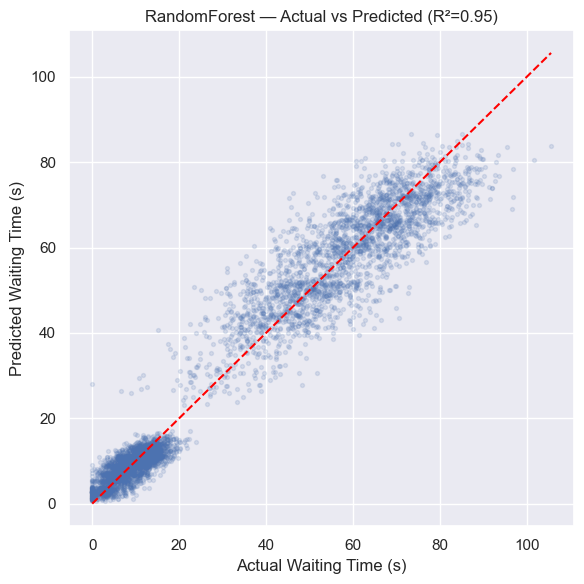

Saved models/waiting_time_regressor.pkl


In [15]:
pred3 = best_reg_pipe.predict(X3_test)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y3_test, pred3, alpha=0.15, s=8)
lims = [0, max(y3_test.max(), pred3.max())]
ax.plot(lims, lims, "--", color="red")
ax.set_xlabel("Actual Waiting Time (s)"); ax.set_ylabel("Predicted Waiting Time (s)")
ax.set_title(f"{best_reg_name} — Actual vs Predicted (R²={best_r2:.2f})")
plt.tight_layout()
plt.show()

joblib.dump(best_reg_pipe, "models/waiting_time_regressor.pkl")
print("Saved models/waiting_time_regressor.pkl")


## 7. Model 4 — Junction Risk Clustering (Unsupervised)

K-Means on aggregated junction-level features. Number of clusters chosen by silhouette score.


In [16]:
agg = df.groupby(["Junction_ID", "Junction_Name"]).agg(
    violation_rate=("Violation", lambda s: (s == "Yes").mean() * 100),
    accident_rate=("Accident", lambda s: (s == "Yes").mean() * 100),
    avg_speed_over=("Speed_Over_Limit", "mean"),
    avg_density=("Traffic_Density", "mean"),
    avg_waiting=("Waiting_Time", "mean"),
    avg_signal_eff=("Signal_Efficiency", "mean"),
).reset_index()

CLUSTER_FEATURES = ["violation_rate", "accident_rate", "avg_speed_over", "avg_density", "avg_waiting", "avg_signal_eff"]
scaler = StandardScaler()
Xs = scaler.fit_transform(agg[CLUSTER_FEATURES].values)

scores = {}
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xs)
    scores[k] = silhouette_score(Xs, labels)

best_k = max(scores, key=scores.get)
print("Silhouette scores:", scores, " -> chosen k =", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
agg["Cluster"] = kmeans.fit_predict(Xs)

cluster_risk = agg.groupby("Cluster")[["violation_rate", "accident_rate"]].mean().sum(axis=1).sort_values()
risk_labels = {c: lbl for c, lbl in zip(cluster_risk.index, ["Low Risk", "Medium Risk", "High Risk", "Critical"][:best_k])}
agg["Risk_Segment"] = agg["Cluster"].map(risk_labels)

agg.sort_values("violation_rate", ascending=False)[["Junction_Name", "violation_rate", "accident_rate", "Risk_Segment"]]


Silhouette scores: {2: np.float64(0.25330296724181145), 3: np.float64(0.29907127497490243), 4: np.float64(0.2776548253309947), 5: np.float64(0.2876361430124516)}  -> chosen k = 3


,Junction_Name,violation_rate,accident_rate,Risk_Segment
8,Industrial Area Junction,42.305476,0.922190,High Risk
14,Civil Lines Junction,40.865955,1.245552,High Risk
3,Railway Station Junction,40.845070,1.971831,High Risk
11,Tech Park Junction,40.812918,1.113586,High Risk
13,Highway Entry Junction,40.454016,1.105937,High Risk
12,Bus Depot Junction,39.104829,1.354535,High Risk
1,College Road Junction,37.929094,1.350591,Medium Risk
9,Riverside Junction,36.384977,0.645540,Medium Risk
2,Market Square Junction,35.744681,1.519757,Medium Risk
5,Stadium Junction,35.641791,0.895522,Low Risk


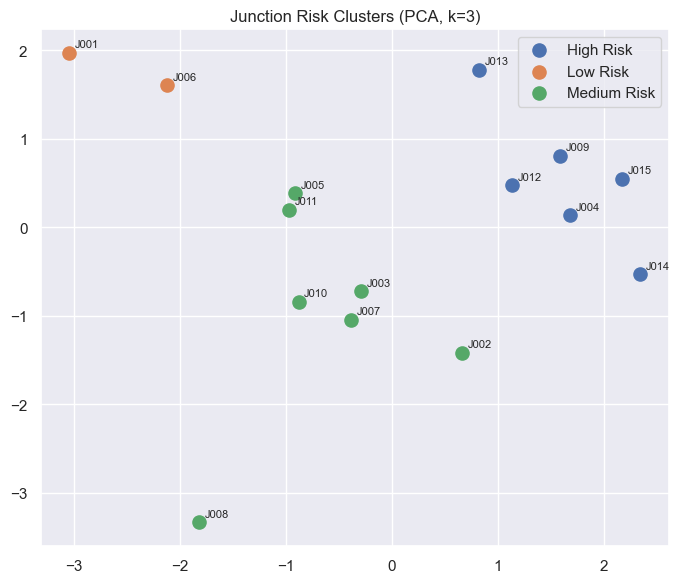

Saved models/junction_risk_clustering.pkl


In [17]:
pca = PCA(n_components=2)
coords = pca.fit_transform(Xs)
agg["PC1"], agg["PC2"] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
for seg, group in agg.groupby("Risk_Segment"):
    ax.scatter(group["PC1"], group["PC2"], label=seg, s=90)
for _, row in agg.iterrows():
    ax.annotate(row["Junction_ID"], (row["PC1"], row["PC2"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_title(f"Junction Risk Clusters (PCA, k={best_k})")
ax.legend()
plt.tight_layout()
plt.show()

joblib.dump({"scaler": scaler, "kmeans": kmeans, "risk_labels": risk_labels, "features": CLUSTER_FEATURES},
            "models/junction_risk_clustering.pkl")
print("Saved models/junction_risk_clustering.pkl")


## 8. Inference demo — using the saved models on new data

In [19]:
violation_clf = joblib.load("models/violation_classifier.pkl")
vtype_bundle = joblib.load("models/violation_type_classifier.pkl")
waiting_reg = joblib.load("models/waiting_time_regressor.pkl")

sample = pd.DataFrame([{
    "Hour": 18, "Is_Peak_Hour": 1, "Is_Weekend": 0,
    "Vehicle_Speed": 78, "Speed_Limit": 60, "Speed_Over_Limit": 18,
    "Traffic_Density": 82.0, "Waiting_Time": 45.0, "Signal_Efficiency": 0.42,
    "Number_of_Lanes": 4, "Lane": 2,
    "Vehicle_Type": "Car", "Signal_State": "Red", "Weather": "Clear",
    "Road_Type": "Main Road", "Junction_Road_Condition": "Average",
    "Direction": "North", "Signal_Type": "Automatic",
}])

pred = violation_clf.predict(sample)[0]
proba = violation_clf.predict_proba(sample)[0, 1]
print(f"Violation prediction: {'VIOLATION' if pred==1 else 'No violation'}  (probability={proba:.2%})")


Violation prediction: VIOLATION  (probability=98.19%)


## 9. Summary

| Task | Model | Metric |
|---|---|---|
| Violation prediction | Random Forest | ROC-AUC ≈ 0.72 |
| Violation type prediction | Random Forest | Macro-F1 ≈ 0.37, Accuracy ≈ 0.63 |
| Waiting time prediction | Random Forest | R² ≈ 0.95, MAE ≈ 4.4s |
| Junction risk clustering | K-Means | Silhouette ≈ 0.30, k=3 |

All models are saved under `models/` and reused by `app.py` (Streamlit dashboard) for interactive predictions.
